# AI-Powered Crop Recommendation System for IoT
## Machine Learning Component - ESP32-S3 Deployment
### Syed Saad Ali Shah | W24060338 | Module: LD7182 - AI for IoT

## 1. Import Libraries

In [25]:
# Core Libraries
import numpy as np
import pandas as pd
import pickle

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Models
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Evaluation Metrics
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix, classification_report

# TensorFlow for model conversion to TFLite
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("All libraries imported successfully!")

All libraries imported successfully!


### Remove Warnings

In [26]:
import os

# Remove TensorFlow warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Disable GPU warnings
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import warnings
warnings.filterwarnings("ignore")

## 2. Data Loading and Exploration

In [27]:
# Load dataset
df = pd.read_csv("Final_CropRecommendation.csv")

# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (2218, 8)

First 5 rows:


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [28]:
# Check data types and missing values
print("Dataset Information:")
df.info()
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2218 entries, 0 to 2217
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2218 non-null   int64  
 1   P            2218 non-null   int64  
 2   K            2218 non-null   int64  
 3   temperature  2218 non-null   float64
 4   humidity     2218 non-null   float64
 5   ph           2218 non-null   float64
 6   rainfall     2218 non-null   float64
 7   label        2218 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 138.8+ KB

Missing Values:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Duplicate Rows: 0


In [29]:
# Statistical summary
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2218.000000,2218.000000,2218.000000,2218.000000,2218.000000,2218.000000,2218.000000
mean,50.680343,53.215960,50.204238,25.612457,71.407950,6.467121,107.240429
std,36.812943,32.902897,107.901985,5.052722,22.212434,0.774239,70.293287
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.770458,60.140227,5.962846,64.740107
50%,37.000000,51.000000,32.000000,25.567257,80.381232,6.422961,95.565760
75%,84.000000,68.000000,49.000000,28.561076,89.900086,6.923909,127.083319
max,140.000000,145.000000,4540.000000,43.675493,99.981876,9.935091,850.736380


In [30]:
# Check unique crop labels
print("Unique Crops:", df['label'].nunique())
print("\nCrop Distribution:")
print(df['label'].value_counts())

Unique Crops: 23

Crop Distribution:
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
wheat           18
Name: count, dtype: int64


## 3. Data Preprocessing

In [31]:
crop_dict = {
    'rice': 1,
    'maize': 2,
    'jute': 3,
    'cotton': 4,
    'coconut': 5,
    'papaya': 6,
    'orange': 7,
    'apple': 8,
    'muskmelon': 9,
    'watermelon': 10,
    'grapes': 11,
    'mango': 12,
    'banana': 13,
    'pomegranate': 14,
    'lentil': 15,
    'blackgram': 16,
    'mungbean': 17,
    'mothbeans': 18,
    'pigeonpeas': 19,
    'kidneybeans': 20,
    'chickpea': 21,
    'coffee': 22,
    'wheat': 23
}

# Reverse mapping for predictions
reverse_crop_dict = {v: k for k, v in crop_dict.items()}

df['numeric_labels'] = df['label'].map(crop_dict)

print("Numeric labels created successfully!")
print("\nLabel Distribution:")
df['numeric_labels'].value_counts().head(10)

Numeric labels created successfully!

Label Distribution:


,count
numeric_labels,
1,100
2,100
21,100
20,100
19,100
18,100
17,100
16,100
15,100


## 4. Exploratory Data Analysis (EDA)

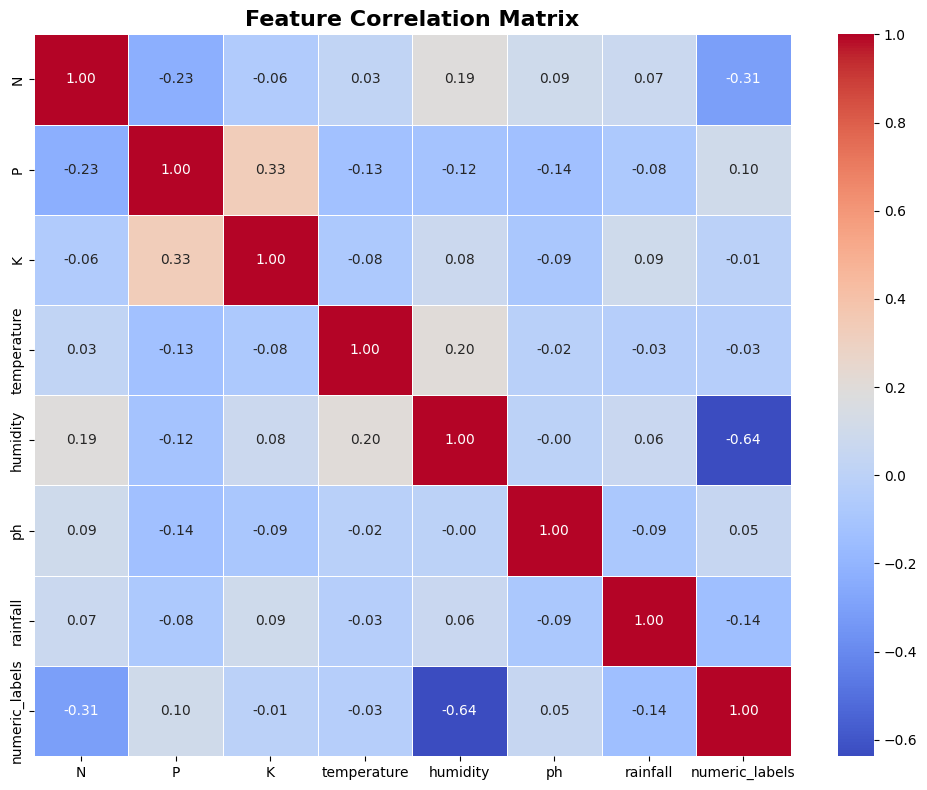

Correlation matrix saved as 'correlation_matrix.png'


In [32]:
# Correlation Matrix
correlation_df = df.drop(['label'], axis=1)
correlation_matrix = correlation_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("Correlation matrix saved as 'correlation_matrix.png'")

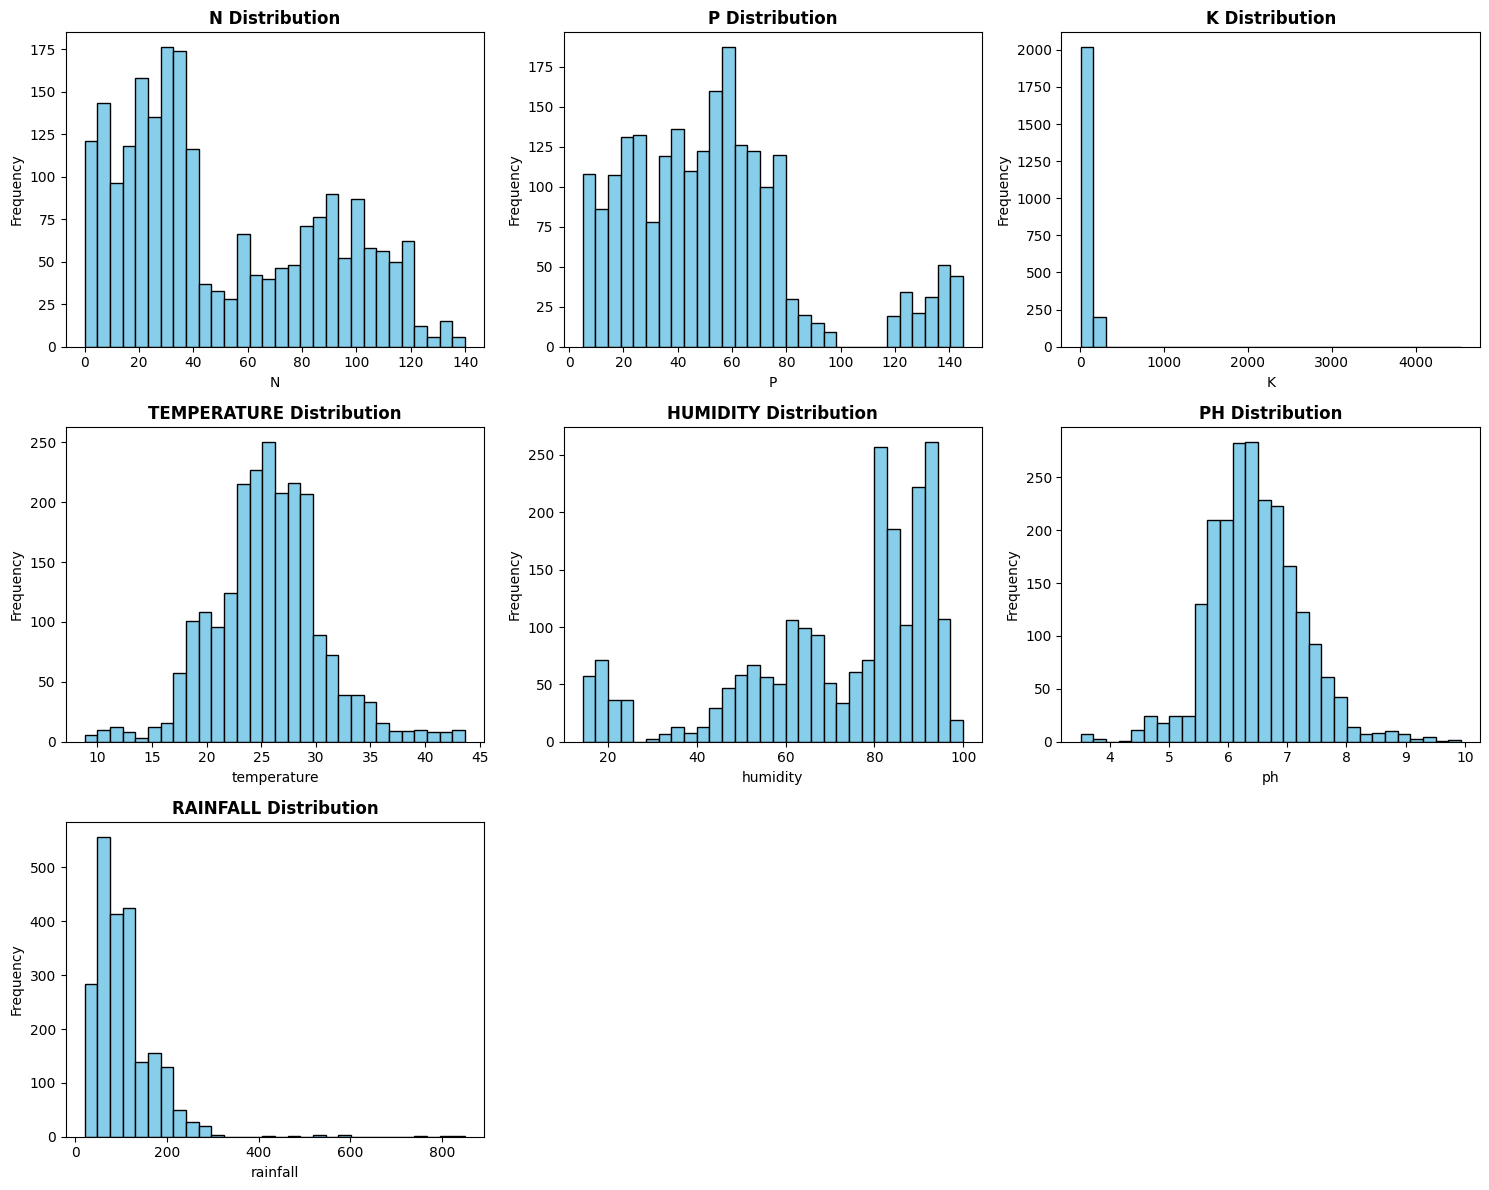

Feature distributions saved as 'feature_distributions.png'


In [33]:
# Feature distributions
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

for idx, feature in enumerate(features):
    row = idx // 3
    col = idx % 3
    axes[row, col].hist(df[feature], bins=30, color='skyblue', edgecolor='black')
    axes[row, col].set_title(f'{feature.upper()} Distribution', fontweight='bold')
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('Frequency')

# Remove extra subplot
fig.delaxes(axes[2, 1])
fig.delaxes(axes[2, 2])

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print("Feature distributions saved as 'feature_distributions.png'")

## 5. Feature and Target Preparation

In [34]:
# Separate features and target
X = df.drop(['numeric_labels', 'label'], axis=1)
Y = df['numeric_labels']

# Check unmapped labels
print(df[df['numeric_labels'].isnull()]['label'].unique())
print("Features shape:", X.shape)
print("Target shape:", Y.shape)
print("\nFeatures:")
print(X.columns.tolist())

[]
Features shape: (2218, 7)
Target shape: (2218,)

Features:
['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']


In [35]:
# Train-test split (80-20)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\nClass distribution in training set:")
print(Y_train.value_counts().head(10))

Training set size: (1774, 7)
Testing set size: (444, 7)

Class distribution in training set:
numeric_labels
20    80
15    80
12    80
14    80
16    80
7     80
11    80
2     80
17    80
5     80
Name: count, dtype: int64


### Normalize features for ML + Neural Network


In [36]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Scaler saved successfully!")

Scaler saved successfully!


## 6. Model Training - Baseline Comparison

In [37]:
# Baseline ML Models
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'KNN': KNeighborsClassifier()
}

model_results = {}

print("\nTraining Classical ML Models...\n")

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(X_train_scaled, Y_train)

    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(Y_test, y_pred)
    f1 = f1_score(Y_test, y_pred, average='macro')
    precision = precision_score(Y_test, y_pred, average='macro')
    recall = recall_score(Y_test, y_pred, average='macro')

    model_results[name] = {
        'Accuracy': accuracy,
        'F1-Score': f1,
        'Precision': precision,
        'Recall': recall
    }

    print(f"{name} Accuracy: {accuracy:.4f}")

print("\nClassical ML Models Completed!")


Training Classical ML Models...

Training Logistic Regression...
Logistic Regression Accuracy: 0.9595
Training Decision Tree...
Decision Tree Accuracy: 0.9887
Training Random Forest...
Random Forest Accuracy: 0.9910
Training KNN...
KNN Accuracy: 0.9662

Classical ML Models Completed!


### Create Results DataFrame

In [38]:

results_df = pd.DataFrame(model_results).T

print("\nModel Comparison:")
print(results_df)


Model Comparison:
                     Accuracy  F1-Score  Precision    Recall
Logistic Regression  0.959459  0.955663   0.963775  0.952174
Decision Tree        0.988739  0.984027   0.989430  0.980435
Random Forest        0.990991  0.986205   0.991511  0.982609
KNN                  0.966216  0.967324   0.969910  0.967391


### Plot comparison of Classic ML Models

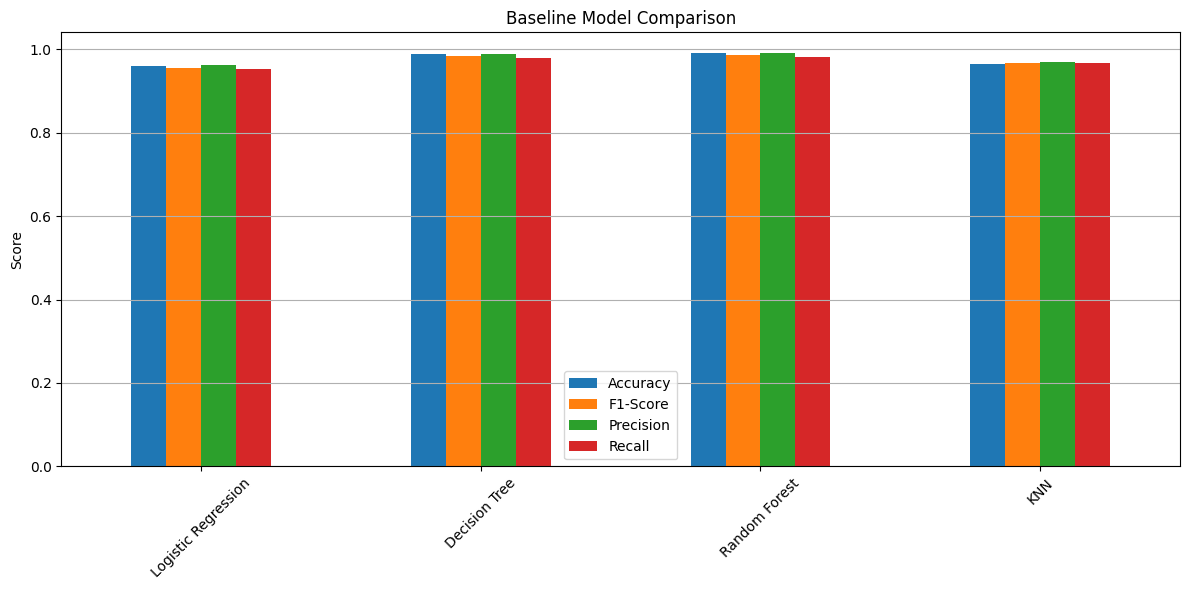

In [39]:

results_df.plot(kind='bar', figsize=(12,6))
plt.title("Baseline Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.savefig("baseline_model_comparison.png")
plt.show()

## 7. TINYML NEURAL NETWORK

In [40]:
# TinyML-Optimized Neural Network
nn_model = keras.Sequential([

    keras.layers.Input(shape=(7,)),

    keras.layers.Dense(32, activation='relu'),

    keras.layers.Dropout(0.2),

    keras.layers.Dense(16, activation='relu'),

    keras.layers.Dense(24, activation='softmax')

])

nn_model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']

)

print("\nTinyML Neural Network Summary:")
nn_model.summary()


TinyML Neural Network Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 24)             │           408 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,192 (4.66 KB)

 Trainable params: 1,192 (4.66 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Train Neural Network

In [41]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Early stopping
early_stop = keras.callbacks.EarlyStopping(

    monitor='val_loss',

    patience=10,

    restore_best_weights=True

)

# Reduce learning rate automatically
reduce_lr = keras.callbacks.ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.5,

    patience=5,

    min_lr=0.00001,

    verbose=1
)

# Train model
history = nn_model.fit(

    X_train_scaled,
    Y_train,

    validation_split=0.2,

    epochs=100,

    batch_size=16,

    callbacks=[early_stop, reduce_lr],

    verbose=1
)

print("\nNeural Network Training Complete!")

Epoch 1/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.0620 - loss: 3.1794 - val_accuracy: 0.1803 - val_loss: 3.0221 - learning_rate: 0.0010
Epoch 2/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1966 - loss: 2.9151 - val_accuracy: 0.3127 - val_loss: 2.7016 - learning_rate: 0.0010
Epoch 3/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2932 - loss: 2.5452 - val_accuracy: 0.3944 - val_loss: 2.2531 - learning_rate: 0.0010
Epoch 4/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3848 - loss: 2.0975 - val_accuracy: 0.4817 - val_loss: 1.7790 - learning_rate: 0.0010
Epoch 5/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4898 - loss: 1.6674 - val_accuracy: 0.6197 - val_loss: 1.3483 - learning_rate: 0.0010
Epoch 6/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6187 - loss: 1.3077 - val_accuracy: 0.7549 - val_loss: 1.0214 - learning_rate: 0.0010
Epoch 7/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6772 - loss: 1.0802 - val_ac

### Training Graphs

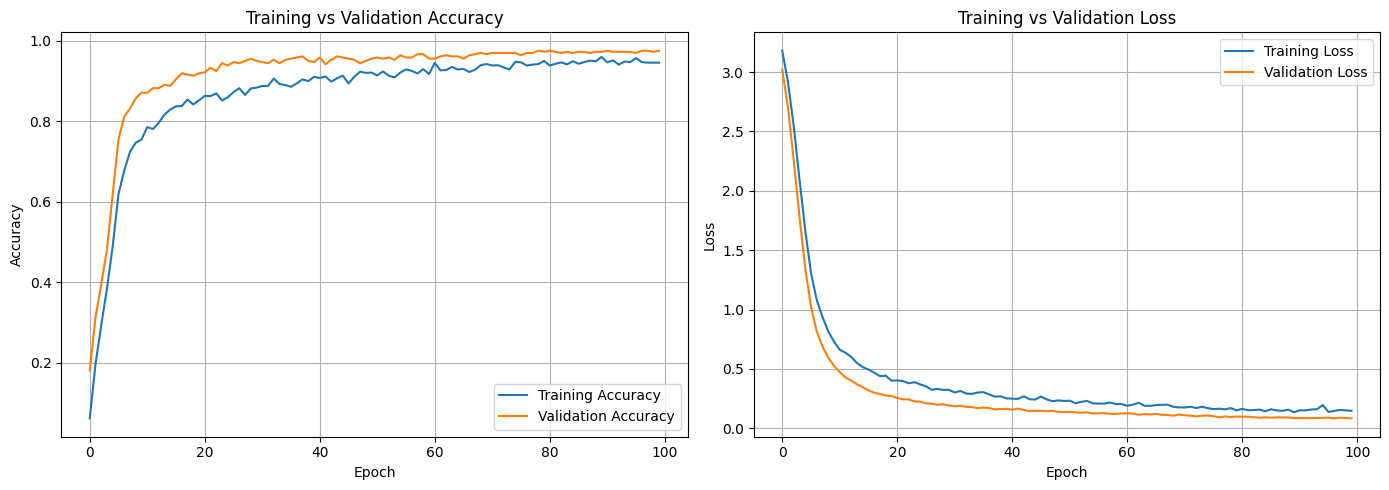

Training graph saved as tinyml_training_graph.png


In [42]:
## Training Graphs

plt.figure(figsize=(14,5))

# Accuracy Graph
plt.subplot(1,2,1)

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend()

plt.grid(True)

# Loss Graph
plt.subplot(1,2,2)

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()

plt.grid(True)

plt.tight_layout()

# Save graph
plt.savefig(
    'tinyml_training_graph.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Training graph saved as tinyml_training_graph.png")

## 9. Evaluate Neural Network

In [43]:
# Predictions
y_prob = nn_model.predict(X_test_scaled)

y_pred = np.argmax(y_prob, axis=1)

# Metrics
accuracy = accuracy_score(Y_test, y_pred)

f1 = f1_score(Y_test, y_pred, average='macro')

precision = precision_score(Y_test, y_pred, average='macro')

recall = recall_score(Y_test, y_pred, average='macro')

print("\n" + "="*50)
print("FINAL DEPLOYED MODEL PERFORMANCE")
print("="*50)

print(f"Accuracy  : {accuracy:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")

print("="*50)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

FINAL DEPLOYED MODEL PERFORMANCE
Accuracy  : 0.9842
F1-Score  : 0.9798
Precision : 0.9855
Recall    : 0.9761


### Visualization of Confusion Matrix

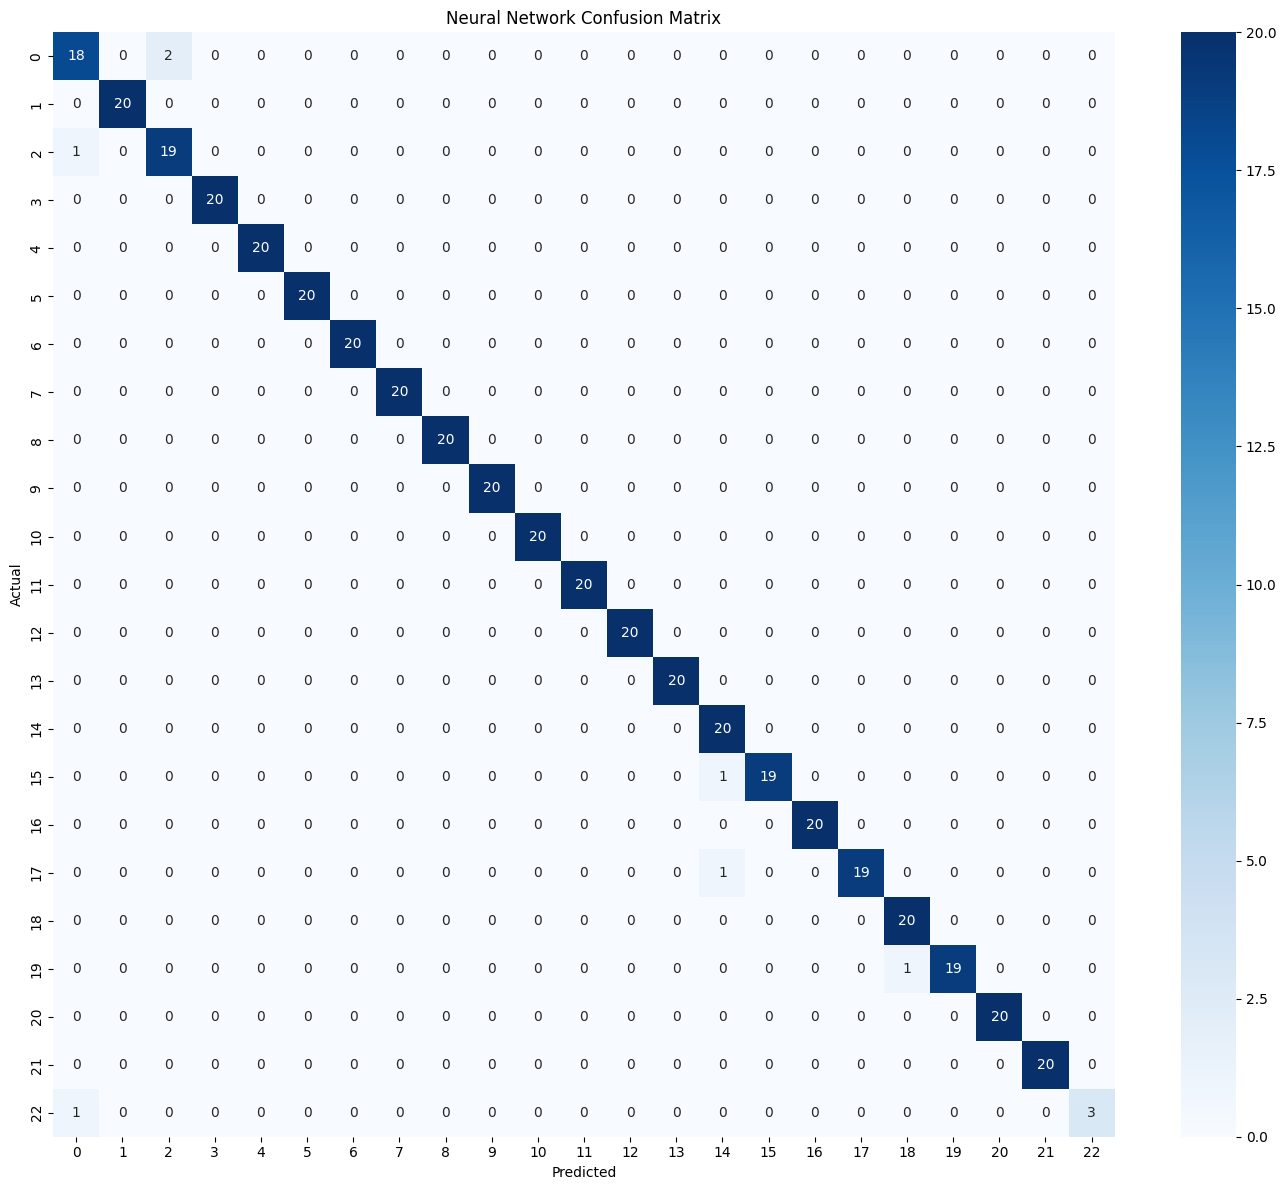

              precision    recall  f1-score   support

           1       0.90      0.90      0.90        20
           2       1.00      1.00      1.00        20
           3       0.90      0.95      0.93        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       1.00      1.00      1.00        20
           9       1.00      1.00      1.00        20
          10       1.00      1.00      1.00        20
          11       1.00      1.00      1.00        20
          12       1.00      1.00      1.00        20
          13       1.00      1.00      1.00        20
          14       1.00      1.00      1.00        20
          15       0.91      1.00      0.95        20
          16       1.00      0.95      0.97        20
          17       1.00      1.00      1.00        20
          18       1.00    

In [44]:


conf_matrix = confusion_matrix(Y_test, y_pred)

plt.figure(figsize=(14,12))

sns.heatmap(

    conf_matrix,

    annot=True,

    fmt='d',

    cmap='Blues'

)

plt.title("Neural Network Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.tight_layout()

plt.savefig("nn_confusion_matrix.png")

plt.show()

# Classification Report
print(classification_report(Y_test, y_pred))

## 10. TFLITE CONVERSION + QUANTIZATION

In [45]:
## 12. Convert to TensorFlow Lite

print("\nConverting to TensorFlow Lite...")

converter = tf.lite.TFLiteConverter.from_keras_model(nn_model)

# Quantization
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

# Save model
with open("crop_recommendation_model.tflite", "wb") as f:

    f.write(tflite_model)

model_size = len(tflite_model) / 1024

print(f"\nTFLite Model Size: {model_size:.2f} KB")

print("TFLite conversion successful!")


Converting to TensorFlow Lite...
Saved artifact at '/tmp/tmpm85flz1l'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 7), dtype=tf.float32, name='keras_tensor_5')
Output Type:
  TensorSpec(shape=(None, 24), dtype=tf.float32, name=None)
Captures:
  136031751209616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136031751209808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136031751214992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136031751214032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136031751210192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136031751210768: TensorSpec(shape=(), dtype=tf.resource, name=None)

TFLite Model Size: 6.74 KB
TFLite conversion successful!


## 11. TinyML Inference Testing

In [46]:
## 13. TinyML Inference Testing

import time

# Load TensorFlow Lite Model
interpreter = tf.lite.Interpreter(

    model_path='crop_recommendation_model.tflite'
)

# Allocate tensors
interpreter.allocate_tensors()

# Get input/output details
input_details = interpreter.get_input_details()

output_details = interpreter.get_output_details()

# Sample Input
sample_input = X_test_scaled[0:1].astype(np.float32)

# Measure inference latency
start_time = time.time()

# Set input tensor
interpreter.set_tensor(

    input_details[0]['index'],

    sample_input
)

# Run inference
interpreter.invoke()

# Get output tensor
output = interpreter.get_tensor(

    output_details[0]['index']
)

# End timer
end_time = time.time()

# Calculate latency
latency_ms = (end_time - start_time) * 1000

# Predicted class
predicted_class = np.argmax(output)

# Actual class
actual_class = Y_test.iloc[0]

# Convert class IDs to crop names
predicted_crop = reverse_crop_dict.get(predicted_class, "Unknown")

actual_crop = reverse_crop_dict.get(actual_class, "Unknown")

# Display Results
print("\nTinyML Inference Results")

print("="*60)

print(f"Predicted Crop ID     : {predicted_class}")

print(f"Predicted Crop Name   : {predicted_crop}")

print(f"Actual Crop ID        : {actual_class}")

print(f"Actual Crop Name      : {actual_crop}")

print(f"\nInference Latency     : {latency_ms:.4f} ms")

print(f"Quantized Model Size  : {model_size:.2f} KB")

print("="*60)


TinyML Inference Results
Predicted Crop ID     : 13
Predicted Crop Name   : banana
Actual Crop ID        : 13
Actual Crop Name      : banana

Inference Latency     : 0.1719 ms
Quantized Model Size  : 6.74 KB


## 12. Generate ESP32 Header File

In [47]:
with open('crop_recommendation_model.tflite', 'rb') as f:

    tflite_binary = f.read()

c_array = ', '.join(

    [f'0x{b:02x}' for b in tflite_binary]

)

header_content = f"""
#ifndef CROP_MODEL_H
#define CROP_MODEL_H

const unsigned char crop_model_tflite[] = {{
{c_array}
}};

const unsigned int crop_model_tflite_len = {len(tflite_binary)};

#endif
"""

with open("crop_model.h", "w") as f:

    f.write(header_content)

print("\nESP32 Header File Generated Successfully!")


ESP32 Header File Generated Successfully!
